# Autoencoders

## A neural network that learns to compress its own input

An autoencoder is a neural network (built from the same dense layers as in the basic neural network notebook) trained to reproduce its own input at the output, after passing it through a narrow *bottleneck* layer. It consists of two parts:

- An **encoder**, $\boldsymbol{z} = f_\mathrm{enc}(\boldsymbol{x})$, that compresses the input $\boldsymbol{x} \in \mathbb{R}^d$ into a lower-dimensional *latent representation* $\boldsymbol{z} \in \mathbb{R}^p$ with $p \ll d$.
- A **decoder**, $\hat{\boldsymbol{x}} = f_\mathrm{dec}(\boldsymbol{z})$, that reconstructs an approximation $\hat{\boldsymbol{x}}$ of the original input from the latent representation.

Both parts are trained jointly, end to end, by minimizing the reconstruction error,

$$
\mathcal{L} = \frac{1}{N}\sum_{i=1}^{N} \lVert \boldsymbol{x}_i - \hat{\boldsymbol{x}}_i \rVert^2
$$

(1)

Crucially, no target labels $\boldsymbol{y}$ are used anywhere — the "label" for each sample is the sample itself, which is why autoencoders are an unsupervised technique despite using the same training machinery (forward propagation, a loss function, backpropagation) as a supervised MLP.

Because the bottleneck $\boldsymbol{z}$ has far fewer dimensions than the input, the network is forced to discover a compact, informative representation of the data — conceptually similar to the goal of PCA in the previous notebook, but the encoder and decoder can implement *nonlinear* transformations of the data,

$$
\boldsymbol{z} = f\!\left( \boldsymbol{W}_\mathrm{enc}\, \boldsymbol{x} + \boldsymbol{b}_\mathrm{enc} \right), \qquad
\hat{\boldsymbol{x}} = g\!\left( \boldsymbol{W}_\mathrm{dec}\, \boldsymbol{z} + \boldsymbol{b}_\mathrm{dec} \right)
$$

(2)

where $f$ and $g$ are (typically nonlinear) activation functions, exactly as in Eq. (1) of the basic neural network notebook.

## Library imports

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn


## Data preparation

We reuse the `digits` data set from the CNN notebook, instead of the wine example in the PCA notebook, since its feature space is already pretty small.

In [16]:
digits = sklearn.datasets.load_digits()
X = digits.data

X_train, X_test = sklearn.model_selection.train_test_split(X, test_size=0.20, random_state=0)

scaler = sklearn.preprocessing.MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Pixel values are rescaled to $[0, 1]$ with a min-max scaler, matching the range of the `logistic` output activation we use in the decoder's last layer below.

## Model definition

`sklearn` has no dedicated autoencoder class, but Eq. (2) is just an ordinary MLP whose output layer has the same size as its input layer, with a narrow hidden layer acting as the bottleneck. We build it with `MLPRegressor`, predicting the input from itself.

In [17]:
bottleneck_size = 8

autoencoder = sklearn.neural_network.MLPRegressor(
    hidden_layer_sizes=(32, bottleneck_size, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=0,
)


The hidden layer sizes `(32, 8, 32)` describe an encoder (64 -> 32 -> 8) and a decoder (8 -> 32 -> 64) sharing the same network, with the 8-unit middle layer as the bottleneck — a much stronger compression than the 64-dimensional input.

## Model training

The targets are simply the (scaled) inputs themselves, Eq. (1).

In [18]:
autoencoder.fit(X_train_scaled, X_train_scaled)

print(f"Final training loss: {autoencoder.loss_:.5f}")


Final training loss: 0.01517


## Model evaluation

We reconstruct the test images and compare them to the originals, both visually and via the mean squared reconstruction error of Eq. (1).

In [19]:
X_test_reconstructed = autoencoder.predict(X_test_scaled)

mse = sklearn.metrics.mean_squared_error(X_test_scaled, X_test_reconstructed)
print(f"Test reconstruction MSE: {mse:.5f}")


Test reconstruction MSE: 0.03243


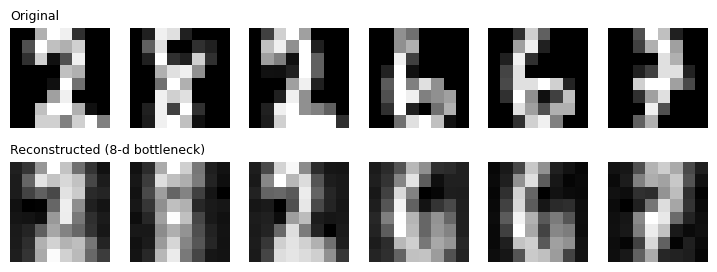

In [20]:
fig, axes = plt.subplots(2, 6, figsize=(9, 3.2))
for i in range(6):
    axes[0, i].imshow(X_test_scaled[i].reshape(8, 8), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(X_test_reconstructed[i].reshape(8, 8), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_title("Original", loc="left", fontsize=9)
axes[1, 0].set_title("Reconstructed (8-d bottleneck)", loc="left", fontsize=9)
plt.show()


## The latent space

The bottleneck activations themselves are an 8-dimensional learned representation of each digit. We can inspect them with PCA (just for visualization) to check whether digits of the same class end up close together in this learned space, without the autoencoder ever having seen the labels.

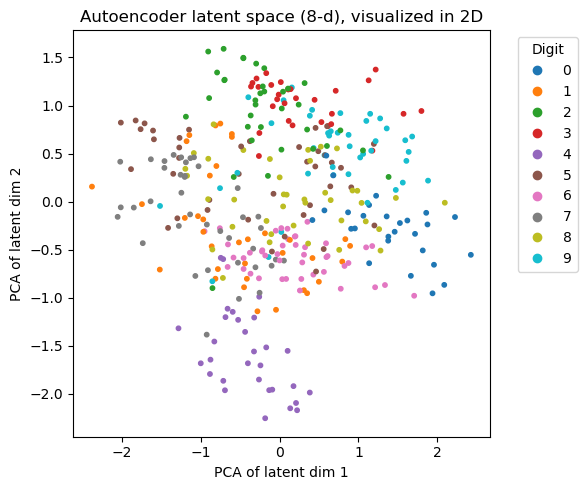

In [21]:
def encode(model, X):
    activation = X
    # forward-propagate through encoder layers only (up to and including the bottleneck)
    n_encoder_layers = 2  # corresponds to hidden_layer_sizes[:2] = (32, bottleneck_size)
    for W, b in zip(model.coefs_[:n_encoder_layers], model.intercepts_[:n_encoder_layers]):
        activation = np.maximum(0, activation @ W + b)
    return activation

Z_test = encode(autoencoder, X_test_scaled)

z_2d = sklearn.decomposition.PCA(n_components=2).fit_transform(Z_test)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=sklearn.model_selection.train_test_split(
    digits.target, test_size=0.20, random_state=0)[1], cmap="tab10", s=10)
plt.xlabel("PCA of latent dim 1"); plt.ylabel("PCA of latent dim 2")
plt.legend(*scatter.legend_elements(), title="Digit", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Autoencoder latent space (8-d), visualized in 2D")
plt.tight_layout()
plt.show()


## Take-away

Autoencoders generalize PCA to nonlinear compression and, being ordinary neural networks, can be extended in many useful directions: denoising (train to reconstruct a clean image from a corrupted input), anomaly detection (samples with unusually high reconstruction error, Eq. (1), are flagged as outliers), or pretraining a network's early layers on unlabeled data before fine-tuning on a smaller labeled data set — all relevant when labeled data is scarce but unlabeled data is plentiful. The trade-off compared to PCA is the usual one for neural networks: more hyperparameters to choose (layer sizes, activation, learning rate) and a non-convex training process with no closed-form solution.